<a href="https://colab.research.google.com/github/wathsan11/Natural-Language-Processing-with-Classification-and-Vector-Spaces/blob/main/NLP_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setup

In [ ]:
import nltk   # Natural Language Toolkit (NLTK)
from nltk.corpus import twitter_samples   # sample Twitter dataset from NLTK
import matplotlib.pyplot as plt
import random

#About the Twitter dataset

In [ ]:
nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.


True

In [ ]:
# select the set of positive and negative tweets

all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

In [ ]:
print('number of positive tweets: ',len(all_positive_tweets))
print('number of negative tweets: ',len(all_negative_tweets))

print('\nThe type of all_positive_tweets: ',type(all_positive_tweets))
print('The type of a tweet entry is: ',type(all_negative_tweets[0]))

number of positive tweets:  5000
number of negative tweets:  5000

The type of all_positive_tweets:  <class 'list'>
The type of a tweet entry is:  <class 'str'>


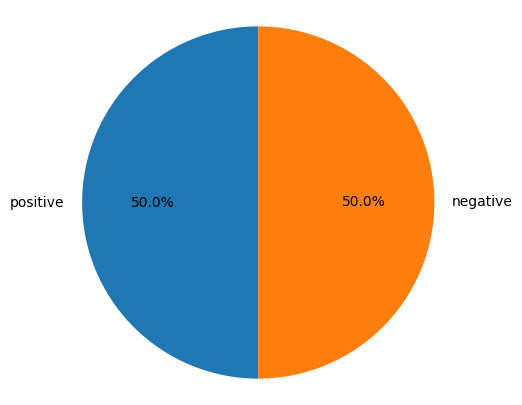

In [ ]:
fig = plt.figure(figsize=(5,5))
labels = 'positive','negative'
sizes = [len(all_positive_tweets),len(all_negative_tweets)]

plt.pie(sizes,labels=labels,autopct='%1.1f%%',shadow=False,startangle=90)   # %1.1f → 1 decimal place  # %% → prints the % symbol
plt.axis('equal') # It makes the pie chart perfectly circular instead of oval.
plt.show()


#Looking at raw texts

In [ ]:
print('\033[92m' + all_positive_tweets[random.randint(0,5000)])
# \033 → escape character (same as \x1b)  [92m → bright green text
# random.randint(0,5000) <-- Returns a random integer between 0 and 5000
print('\n\033[93m' + all_negative_tweets[random.randint(0,5000)])

@Eric_Yeomans I stashed 3 of your closer-chasing specs in a league I am chasing saves...so yes...the walls have ears! :-)

That was the quickest blood test ever but my arm hurts :(


#Preprocess raw text for Sentiment analysis

In [ ]:
tweet = all_positive_tweets[2277]
print('\x1b[96m'+tweet)

My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i


In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import re       # # library for regular expression operations
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

###Remove hyperlinks, Twitter marks and styles

In [ ]:
print()
print('\33[96m' + tweet)
print('\33[93m')

# remove old style retweet text "RT"
tweet2 = re.sub(r'^RT[\s]+', '', tweet)          # re.sub(pattern, replacement, text)

# remove hyperlinks
tweet2 = re.sub(r'https?://[^\s\n\r]+','',tweet2)

# remove hashtags. only removing the hash # sign from the word
tweet2 = re.sub(r'#',"",tweet2)
print(tweet2)


My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i

My beautiful sunflowers on a sunny Friday morning off :) sunflowers favourites happy Friday off… 


###Tokenize the string

In [ ]:
print()
print('\33[93m'+ tweet2)
print('\33[97m')

tokenizer = TweetTokenizer(preserve_case=False, strip_handles= True,reduce_len=True)
# preserve_case=False <- Converts everything to lowercase
# strip_handles=True <- Removes @username
# reduce_len=True <- Shortens repeated characters. reduces long repetitions to maximum 3 characters

tweet_Tokens = tokenizer.tokenize(tweet2)

print()
print('Tokenized string:')
print(tweet_Tokens)
print()


My beautiful sunflowers on a sunny Friday morning off :) sunflowers favourites happy Friday off… 


Tokenized string:
['my', 'beautiful', 'sunflowers', 'on', 'a', 'sunny', 'friday', 'morning', 'off', ':)', 'sunflowers', 'favourites', 'happy', 'friday', 'off', '…']



###Remove stop words and punctuations

In [ ]:
stopwords_English = stopwords.words('english')
print('Stop_Words\n')
print(stopwords_English)

Stop_Words

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "s

In [ ]:
print('Puntuations\n')
print(string.punctuation)

Puntuations

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [ ]:
print()
print('\33[97m')
print(tweet_Tokens)
print()
print('\33[93m')

tweets_clean = []

for word in tweet_Tokens:
  if(word not in stopwords_English and word not in string.punctuation):
    tweets_clean.append(word)

print('removed stop words and punctuation:')
print()
print(tweets_clean)



['my', 'beautiful', 'sunflowers', 'on', 'a', 'sunny', 'friday', 'morning', 'off', ':)', 'sunflowers', 'favourites', 'happy', 'friday', 'off', '…']


removed stop words and punctuation:

['beautiful', 'sunflowers', 'sunny', 'friday', 'morning', ':)', 'sunflowers', 'favourites', 'happy', 'friday', '…']


###Stemming

eg :- learn  
 learning  
learned  
learnt

In [ ]:
print()
print('\33[97m')
print(tweets_clean)
print()
print('\33[92m')

tweets_stem = []

stemmer = PorterStemmer()

for word in tweets_clean:
  stem_word = stemmer.stem(word)
  tweets_stem.append(stem_word)

print("stemmed words")
print(tweets_stem)
print()



['beautiful', 'sunflowers', 'sunny', 'friday', 'morning', ':)', 'sunflowers', 'favourites', 'happy', 'friday', '…']


stemmed words
['beauti', 'sunflow', 'sunni', 'friday', 'morn', ':)', 'sunflow', 'favourit', 'happi', 'friday', '…']



#process_tweet()

a funtion which do all above processes.<br>
Cleans the text, tokenizes it into separate words, removes stopwords, and converts words to stems.

In [ ]:
def process_tweet(tweet):
    """Process tweet function.
    Input:
        tweet: a string containing a tweet
    Output:
        tweets_clean: a list of words containing the processed tweet

    """
    stemmer = PorterStemmer()
    stopwords_english = stopwords.words('english')
    # remove stock market tickers like $GE
    tweet = re.sub(r'\$\w*', '', tweet)
    # remove old style retweet text "RT"
    tweet = re.sub(r'^RT[\s]+', '', tweet)
    # remove hyperlinks
    tweet = re.sub(r'https?://[^\s\n\r]+', '', tweet)
    # remove hashtags
    # only removing the hash # sign from the word
    tweet = re.sub(r'#', '', tweet)
    # tokenize tweets
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)
    tweet_tokens = tokenizer.tokenize(tweet)

    tweets_clean = []
    for word in tweet_tokens:
        if (word not in stopwords_english and  # remove stopwords
                word not in string.punctuation):  # remove punctuation
            # tweets_clean.append(word)
            stem_word = stemmer.stem(word)  # stemming word
            tweets_clean.append(stem_word)

    return tweets_clean

In [ ]:
tweet = all_positive_tweets[2277]

print()
print('\033[92m')
print(tweet)
print('\033[94m')

# call the imported function
tweets_stem = process_tweet(tweet); # Preprocess a given tweet

print('preprocessed tweet:')
print(tweets_stem) # Print the result



My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i

preprocessed tweet:
['beauti', 'sunflow', 'sunni', 'friday', 'morn', ':)', 'sunflow', 'favourit', 'happi', 'friday', '…']
